<a href="https://colab.research.google.com/github/Tanish-ops7710/DAFA1/blob/main/FAQUES5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "dataset_2026-07-26T06_08_50.841086747Z_DEFAULT_INTEGRATION_IMF.STA_ANEA_6.0.1.csv",
    low_memory=False
)

print(df.shape)

(13493, 119)


In [3]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13493 entries, 0 to 13492
Columns: 119 entries, DATASET to 2025
dtypes: float64(90), object(29)
memory usage: 12.3+ MB
None

Missing Values:
DATASET            0
SERIES_CODE        0
OBS_MEASURE        0
COUNTRY            0
INDICATOR          0
               ...  
2021            9377
2022            9483
2023            9673
2024           10223
2025           11264
Length: 119, dtype: int64


In [4]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows where COUNTRY is missing
df = df.dropna(subset=["COUNTRY"])

print("Dataset Shape After Cleaning:")
print(df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Dataset Shape After Cleaning:
(13493, 119)

Missing Values After Cleaning:
DATASET            0
SERIES_CODE        0
OBS_MEASURE        0
COUNTRY            0
INDICATOR          0
               ...  
2021            9377
2022            9483
2023            9673
2024           10223
2025           11264
Length: 119, dtype: int64


In [5]:
# Display all unique indicators
print(df["INDICATOR"].dropna().unique())

['Imports of services' 'Statistical discrepancy (expenditure approach)'
 'Exports of services' 'Exports of goods' 'Imports of goods'
 'Gross domestic product (GDP)' 'Imports of goods and services'
 'Exports of goods and services' 'External balance of goods and services'
 'Final consumption expenditure, General government'
 'Final consumption expenditure, Private sector' 'Changes in inventories'
 'Gross fixed capital formation' 'Gross capital formation'
 'Final consumption expenditure'
 'Final consumption expenditure, Households'
 'Changes in inventories, Private sector'
 'Final consumption expenditure, Non profit institutions serving households'
 'Final consumption expenditure, Households and non profit institutions serving households (NPISH)'
 'Individual consumption expenditure, General government'
 'Collective consumption expenditure, General government'
 'Acquisitions less disposals of fixed assets non-residential structures'
 'Acquisitions less disposals of valuables'
 'Gross valu

In [8]:
gdp = df[df["INDICATOR"] == "Gross domestic product (GDP)"]

print(gdp.shape)
gdp.head()

(953, 119)


,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,PRICE_TYPE,TYPE_OF_TRANSFORMATION,FREQUENCY,SCALE,DECIMALS_DISPLAYED,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
8,IMF.STA:ANEA(6.0.1),SYC.B1GQ.Q.XDC.A,OBS_VALUE,Seychelles,Gross domestic product (GDP),Constant prices,Domestic currency,Annual,NaN,NaN,...,2.159851e+10,2.310050e+10,2.424155e+10,2.557829e+10,2.257544e+10,2.270012e+10,2.609988e+10,2.596448e+10,NaN,NaN
16,IMF.STA:ANEA(6.0.1),SYR.B1GQ.V.XDC.A,OBS_VALUE,Syrian Arab Republic,Gross domestic product (GDP),Current prices,Domestic currency,Annual,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,IMF.STA:ANEA(6.0.1),SYR.B1GQ.Q.XDC.A,OBS_VALUE,Syrian Arab Republic,Gross domestic product (GDP),Constant prices,Domestic currency,Annual,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,IMF.STA:ANEA(6.0.1),VNM.B1GQ.Q.XDC.A,OBS_VALUE,Vietnam,Gross domestic product (GDP),Constant prices,Domestic currency,Annual,NaN,NaN,...,3.944144e+15,4.217875e+15,4.532739e+15,4.866316e+15,5.005756e+15,5.133589e+15,5.571869e+15,5.854086e+15,6.269210e+15,NaN
22,IMF.STA:ANEA(6.0.1),VNM.B1GQ.V.XDC.A,OBS_VALUE,Vietnam,Gross domestic product (GDP),Current prices,Domestic currency,Annual,NaN,NaN,...,5.639401e+15,6.293905e+15,7.009042e+15,7.707200e+15,8.044386e+15,8.487476e+15,9.621372e+15,1.032031e+16,1.151187e+16,NaN


In [9]:
gdp = df[
    (df["INDICATOR"] == "Gross domestic product (GDP)") &
    (df["PRICE_TYPE"] == "Constant prices")
]

print(gdp.shape)

gdp.head()

(388, 119)


,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,PRICE_TYPE,TYPE_OF_TRANSFORMATION,FREQUENCY,SCALE,DECIMALS_DISPLAYED,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
8,IMF.STA:ANEA(6.0.1),SYC.B1GQ.Q.XDC.A,OBS_VALUE,Seychelles,Gross domestic product (GDP),Constant prices,Domestic currency,Annual,NaN,NaN,...,2.159851e+10,2.310050e+10,2.424155e+10,2.557829e+10,2.257544e+10,2.270012e+10,2.609988e+10,2.596448e+10,NaN,NaN
19,IMF.STA:ANEA(6.0.1),SYR.B1GQ.Q.XDC.A,OBS_VALUE,Syrian Arab Republic,Gross domestic product (GDP),Constant prices,Domestic currency,Annual,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,IMF.STA:ANEA(6.0.1),VNM.B1GQ.Q.XDC.A,OBS_VALUE,Vietnam,Gross domestic product (GDP),Constant prices,Domestic currency,Annual,NaN,NaN,...,3.944144e+15,4.217875e+15,4.532739e+15,4.866316e+15,5.005756e+15,5.133589e+15,5.571869e+15,5.854086e+15,6.269210e+15,NaN
209,IMF.STA:ANEA(6.0.1),MMR.B1GQ.Q.USD.A,OBS_VALUE,Myanmar,Gross domestic product (GDP),Constant prices,US dollar,Annual,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
218,IMF.STA:ANEA(6.0.1),SYC.B1GQ.Q.USD.A,OBS_VALUE,Seychelles,Gross domestic product (GDP),Constant prices,US dollar,Annual,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
years = [str(year) for year in range(2000, 2024)]

gdp_years = gdp[years]

print(gdp_years.head())

             2000          2001          2002          2003          2004  \
8             NaN           NaN           NaN           NaN           NaN   
19   9.471300e+11  9.819830e+11  1.039888e+12  1.018708e+12  1.089026e+12   
20            NaN           NaN           NaN           NaN  1.477161e+15   
209           NaN           NaN           NaN           NaN           NaN   
218           NaN           NaN           NaN           NaN           NaN   

             2005          2006          2007          2008          2009  \
8             NaN           NaN           NaN           NaN           NaN   
19   1.156714e+12  1.215082e+12  1.284035e+12  1.341515e+12  1.420832e+12   
20   1.588646e+15  1.699501e+15  1.820667e+15  1.923749e+15  2.027591e+15   
209           NaN           NaN           NaN           NaN           NaN   
218           NaN           NaN           NaN           NaN           NaN   

     ...          2014          2015          2016          2017  \
8    .

In [11]:
gdp_years = gdp_years.apply(pd.to_numeric, errors='coerce')

print(gdp_years.info())

<class 'pandas.core.frame.DataFrame'>
Index: 388 entries, 8 to 13435
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   2000    108 non-null    float64
 1   2001    108 non-null    float64
 2   2002    109 non-null    float64
 3   2003    111 non-null    float64
 4   2004    118 non-null    float64
 5   2005    122 non-null    float64
 6   2006    131 non-null    float64
 7   2007    138 non-null    float64
 8   2008    141 non-null    float64
 9   2009    142 non-null    float64
 10  2010    155 non-null    float64
 11  2011    156 non-null    float64
 12  2012    159 non-null    float64
 13  2013    162 non-null    float64
 14  2014    166 non-null    float64
 15  2015    169 non-null    float64
 16  2016    174 non-null    float64
 17  2017    175 non-null    float64
 18  2018    178 non-null    float64
 19  2019    182 non-null    float64
 20  2020    182 non-null    float64
 21  2021    182 non-null    float64
 22  2022 

In [12]:
gdp_clean = gdp_years.dropna()

print(gdp_clean.shape)

(105, 24)


In [16]:
print("Cleaned GDP Dataset Shape:")
print(gdp_clean.shape)

print("\nFirst Five Rows:")
print(gdp_clean.head())

Cleaned GDP Dataset Shape:
(105, 24)

First Five Rows:
              2000          2001          2002          2003          2004  \
282   2.661280e+10  2.332489e+10  2.536708e+10  2.612947e+10  2.543560e+10   
5184  1.711163e+12  1.771466e+12  1.827896e+12  1.886270e+12  1.963457e+12   
5497  1.900435e+10  1.988096e+10  1.972508e+10  1.929218e+10  1.967657e+10   
5580  2.566900e+10  3.090300e+10  3.577600e+10  4.189200e+10  4.804700e+10   
5636  2.682937e+09  2.865709e+09  3.112655e+09  3.278011e+09  3.445159e+09   

              2005          2006          2007          2008          2009  \
282   2.580486e+10  2.555475e+10  2.591937e+10  2.088173e+10  2.342497e+10   
5184  2.051258e+12  2.191643e+12  2.346982e+12  2.514939e+12  2.632477e+12   
5497  2.022351e+10  2.116791e+10  2.222217e+10  2.421110e+10  2.565938e+10   
5580  5.431200e+10  6.026900e+10  6.693300e+10  7.680400e+10  8.151400e+10   
5636  3.540853e+09  3.889804e+09  3.688198e+09  3.844429e+09  3.984994e+09   

      .

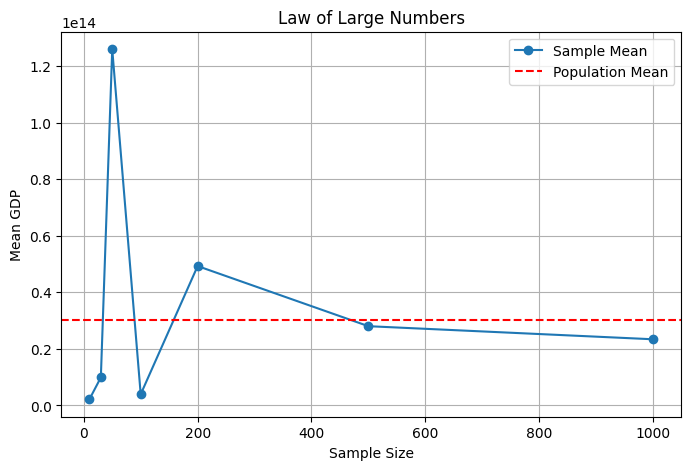

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Convert GDP values into one long array
gdp_values = gdp_clean.values.flatten()
gdp_values = gdp_values[~np.isnan(gdp_values)]

# Overall population mean
population_mean = np.mean(gdp_values)

# Sample sizes
sample_sizes = [10, 30, 50, 100, 200, 500, 1000]

sample_means = []

for size in sample_sizes:
    sample = np.random.choice(gdp_values, size=size, replace=True)
    sample_means.append(np.mean(sample))

# Plot
plt.figure(figsize=(8,5))
plt.plot(sample_sizes, sample_means, marker='o', label='Sample Mean')
plt.axhline(population_mean, color='red', linestyle='--', label='Population Mean')
plt.xlabel("Sample Size")
plt.ylabel("Mean GDP")
plt.title("Law of Large Numbers")
plt.legend()
plt.grid(True)
plt.show()

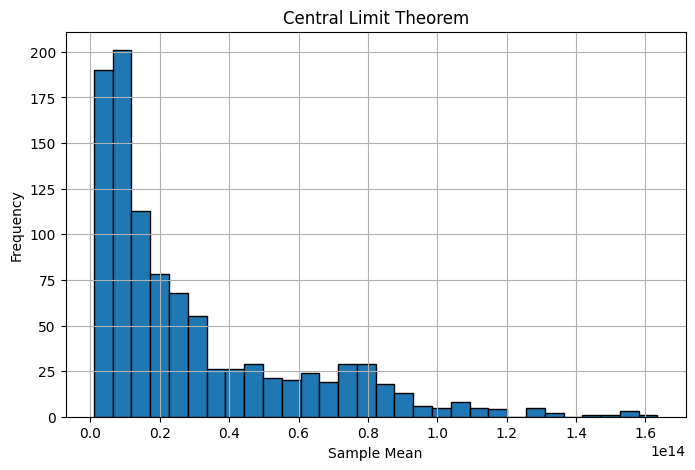

In [14]:
sample_means = []

for i in range(1000):
    sample = np.random.choice(gdp_values, size=30, replace=True)
    sample_means.append(np.mean(sample))

plt.figure(figsize=(8,5))
plt.hist(sample_means, bins=30, edgecolor='black')
plt.title("Central Limit Theorem")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [15]:
mean = np.mean(gdp_values)

a = 2 * mean

markov_bound = mean / a

print("Mean GDP:", mean)
print("Threshold (a):", a)
print("Markov Bound:", markov_bound)

Mean GDP: 30057262246512.812
Threshold (a): 60114524493025.625
Markov Bound: 0.5
